# Exoplanet Detection using Machine Learning
În decursul acestei lucrări vom încerca să detectăm exoplanete care orbitează în jurul unor stele masive. Metoda folosită pe parcursul lucrării pentru detectarea exoplanetelor se numește Metoda Tranziției. Atunci când o planetă de dimensiuni asemănătoare cu Jupiter trece prin fața unei stele masive, lumina emisă de stea în acea direcție scade. Aceste planete se numesc în literatura de specialitate Jupiteri Fierbinți.

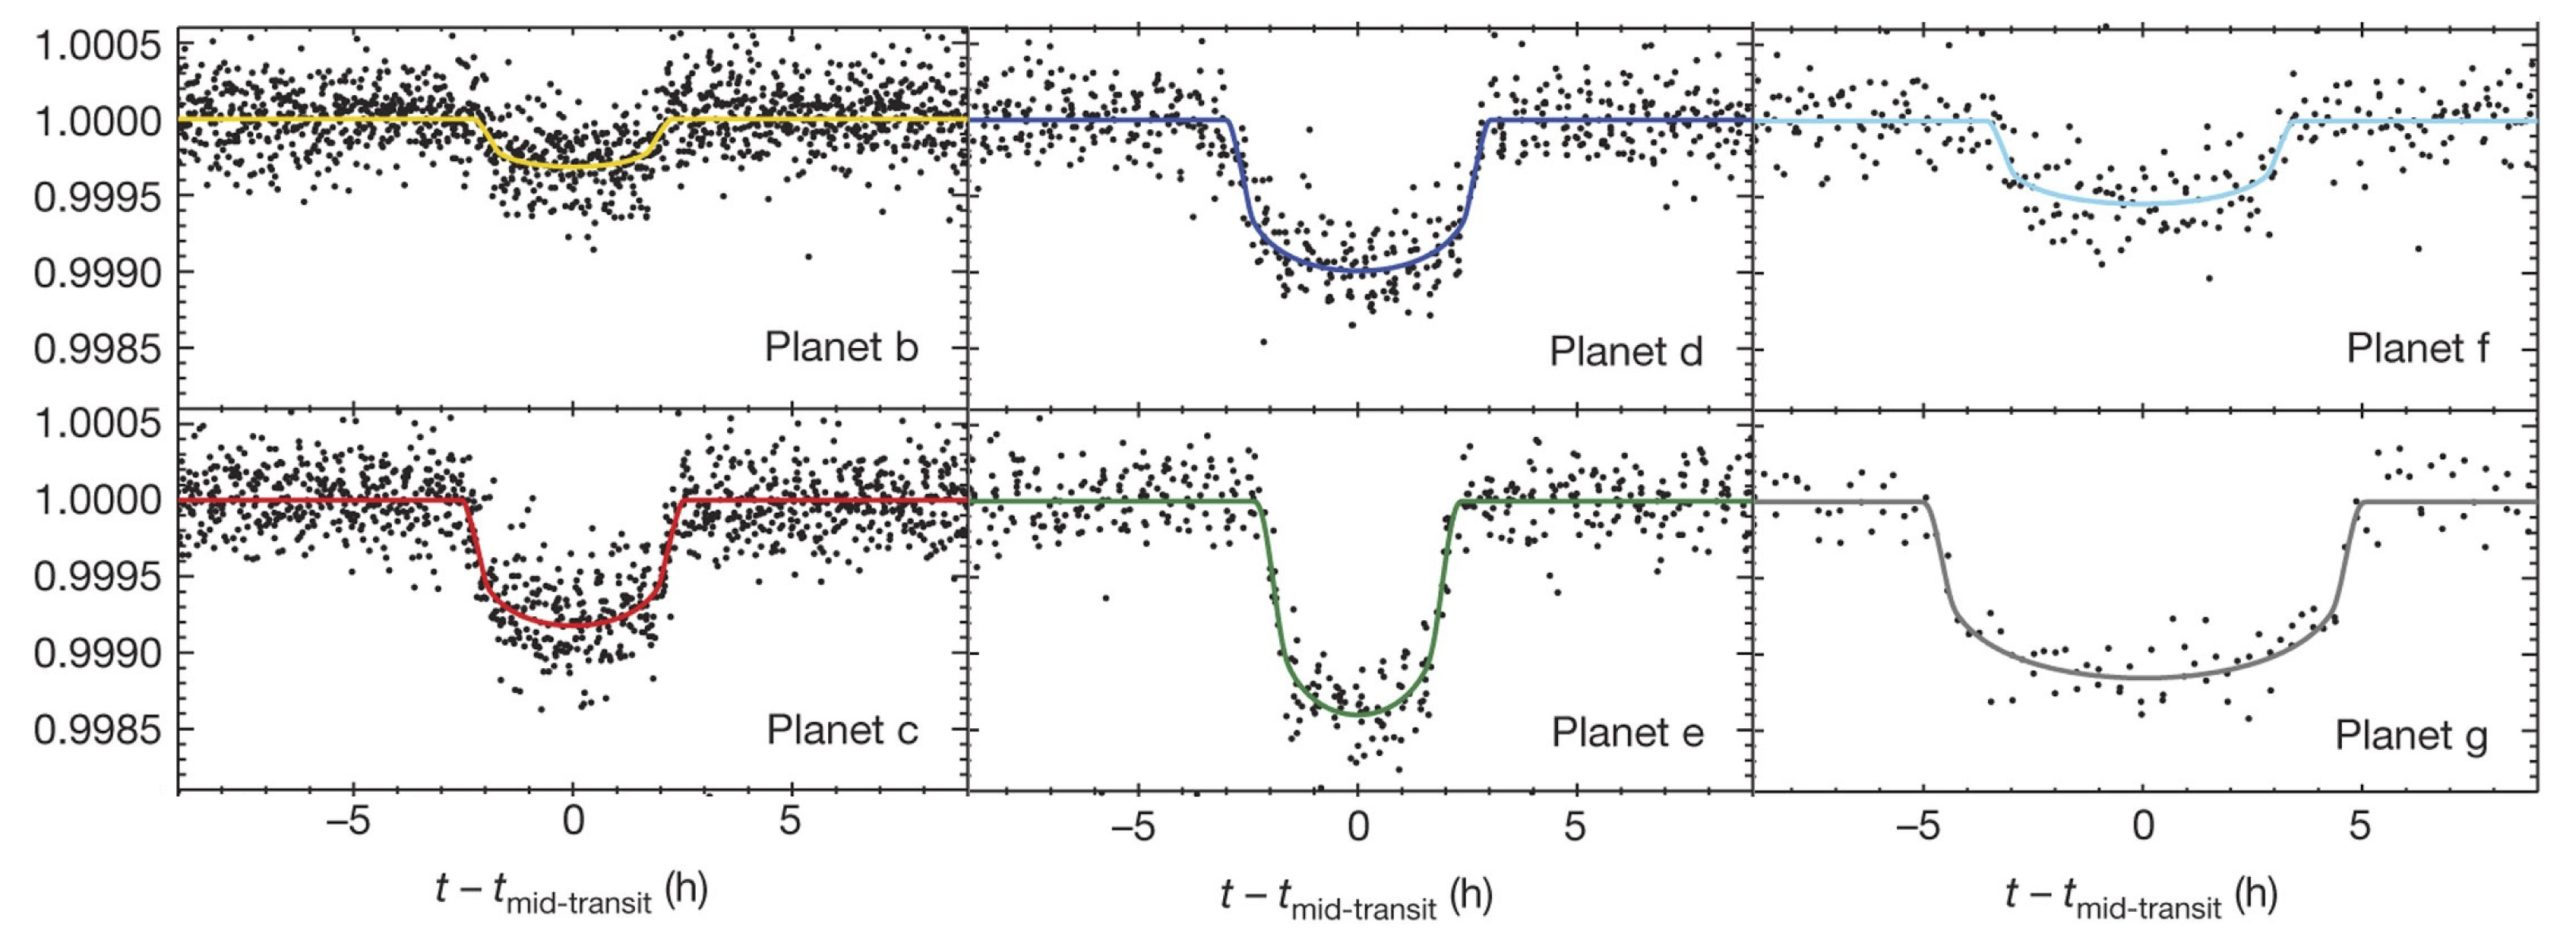






Setul de date numit exoTrail.csv reprezintă date colectate de Kepler Space Telescope, lansat de NASA. Acesta a înregistrat fluxul luminos emis 5086 de stele, la intervale regulate de timp. În fișierul .csv avem 3197 de valori de flux pentru fiecare stea. Fluxurile reprezintă coloanele tabelului, iar fiecare stea reprezintă o linie din tabel. De exemplu pe linia 2 din tabel, vom avea fluxurile de lumină emise de steaua numărul 2. De asemenea avem o coloană pentru etichetă care ne spune dacă acea stea are o exoplanetă care orbitează în jurul său. Dacă label=1, nu există exoplanetă, dacă label=2 atunci există exoplanetă.

### Relația dintre dimensiunea planetei și scăderea fluxului luminos

Atunci când o planetă trece prin fața unei stele (fenomen numit **tranzit planetar**), ea blochează o mică parte din lumina emisă de stea. Telescopul măsoară această scădere temporară a luminozității sub forma unei mici scăderi în curba de lumină (light curve).

Scăderea relativă a fluxului luminos este aproximativ:

$$
\frac{\Delta F}{F} \approx \left(\frac{R_p}{R_s}\right)^2
$$

unde:

- $F$ este fluxul luminos al stelei
- $\Delta F$ este scăderea fluxului în timpul tranzitului
- $R_p$ este raza planetei
- $R_s$ este raza stelei

Fizic, această relație apare deoarece planeta acoperă o parte din suprafața aparentă a stelei. Scăderea luminii este aproximativ egală cu raportul dintre **aria planetei** și **aria stelei**.

Deoarece aria unui disc este:

$$
A = \pi R^2
$$

raportul ariilor devine:

$$
\frac{\text{aria planetei}}{\text{aria stelei}} =
\frac{\pi R_p^2}{\pi R_s^2} =
\left(\frac{R_p}{R_s}\right)^2
$$

Prin urmare, scăderea fluxului luminos este proporțională cu **pătratul raportului dintre raza planetei și raza stelei**.

### Exemple intuitive

**Planetă mică (similară cu Pământul)**

Dacă:

$$
R_p \approx 0.009 R_s
$$

atunci scăderea fluxului este aproximativ:

$$
\Delta F/F \approx 0.00008
$$

adică aproximativ **0.008% scădere a luminii**.

**Planetă mare (similară cu Jupiter)**

Dacă:

$$
R_p \approx 0.1 R_s
$$

atunci:

$$
\Delta F/F \approx 0.01
$$

adică aproximativ **1% scădere a luminozității stelei**.

Acesta este principiul fizic care permite detectarea exoplanetelor folosind metoda tranzitului.



Mounted at /content/drive
Dataset shape:  (5087, 3198)

First rows:
   LABEL   FLUX.1   FLUX.2   FLUX.3   FLUX.4  ...  FLUX.3193  FLUX.3194  \
0      2    93.85    83.81    20.10   -26.98  ...      92.54      39.32   
1      2   -38.88   -33.83   -58.54   -40.09  ...       0.76     -11.70   
2      2   532.64   535.92   513.73   496.92  ...       5.06     -11.80   
3      2   326.52   347.39   302.35   298.13  ...     -12.67      -8.77   
4      2 -1107.21 -1112.59 -1118.95 -1095.10  ...    -438.54    -399.71   

   FLUX.3195  FLUX.3196  FLUX.3197  
0      61.42       5.08     -39.54  
1       6.46      16.00      19.93  
2     -28.91     -70.02     -96.67  
3     -17.31     -17.35      13.98  
4    -384.65    -411.79    -510.54  

[5 rows x 3198 columns]
Stars with exoplanets: 37
Stars without exoplanets: 5050


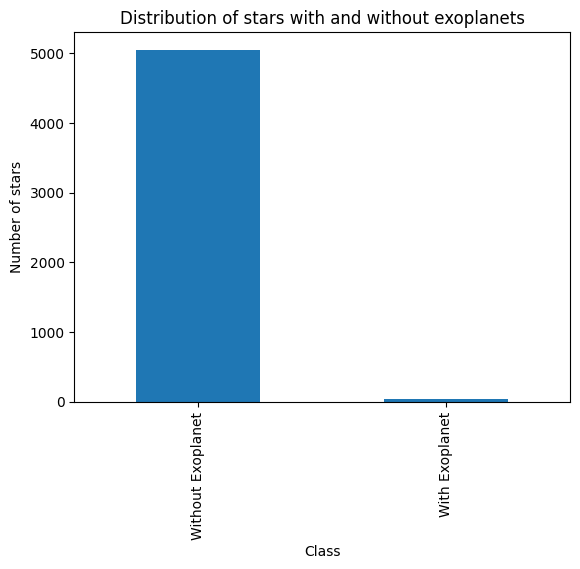

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/exoTrain.csv")
test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/exoTest.csv")

print("Dataset shape: ", train.shape)
pd.set_option('display.max_columns', 10)
print("\nFirst rows:")
print(train.head())

train["LABEL"].value_counts()

no_planets = (train["LABEL"] == 1).sum()
planets = (train["LABEL"] == 2).sum()

print("Stars with exoplanets:", planets)
print("Stars without exoplanets:", no_planets)

train["LABEL"].value_counts().plot(kind="bar")

plt.title("Distribution of stars with and without exoplanets")
plt.xlabel("Class")
plt.ylabel("Number of stars")

plt.xticks([0,1], ["Without Exoplanet", "With Exoplanet"])

plt.show()

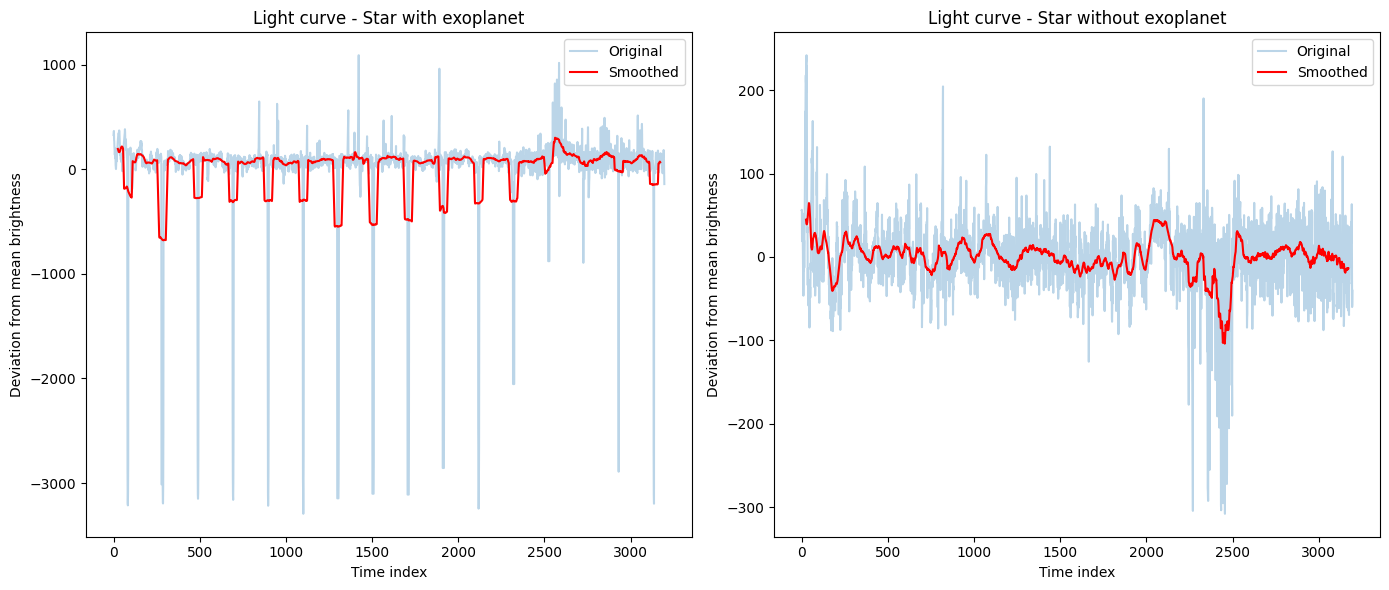

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

#check the 7'th star
star_with_planet = train[train["LABEL"] == 2].iloc[7]
flux_with_planet = star_with_planet.drop("LABEL").astype(float)


star_without_planet = train[train["LABEL"] == 1].iloc[100]
flux_without_planet = star_without_planet.drop("LABEL").astype(float)


flux_with_planet = flux_with_planet - flux_with_planet.mean()
flux_without_planet = flux_without_planet - flux_without_planet.mean()


window = 50
smooth_with_planet = pd.Series(flux_with_planet).rolling(window=window, center=True).mean()
smooth_without_planet = pd.Series(flux_without_planet).rolling(window=window, center=True).mean()


plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(flux_with_planet.values, alpha=0.3, label="Original")
plt.plot(smooth_with_planet.values, color="red", label="Smoothed")
plt.title("Light curve - Star with exoplanet")
plt.xlabel("Time index")
plt.ylabel("Deviation from mean brightness")
plt.legend()

plt.subplot(1,2,2)
plt.plot(flux_without_planet.values, alpha=0.3, label="Original")
plt.plot(smooth_without_planet.values, color="red", label="Smoothed")
plt.title("Light curve - Star without exoplanet")
plt.xlabel("Time index")
plt.ylabel("Deviation from mean brightness")
plt.legend()

plt.tight_layout()
plt.show()

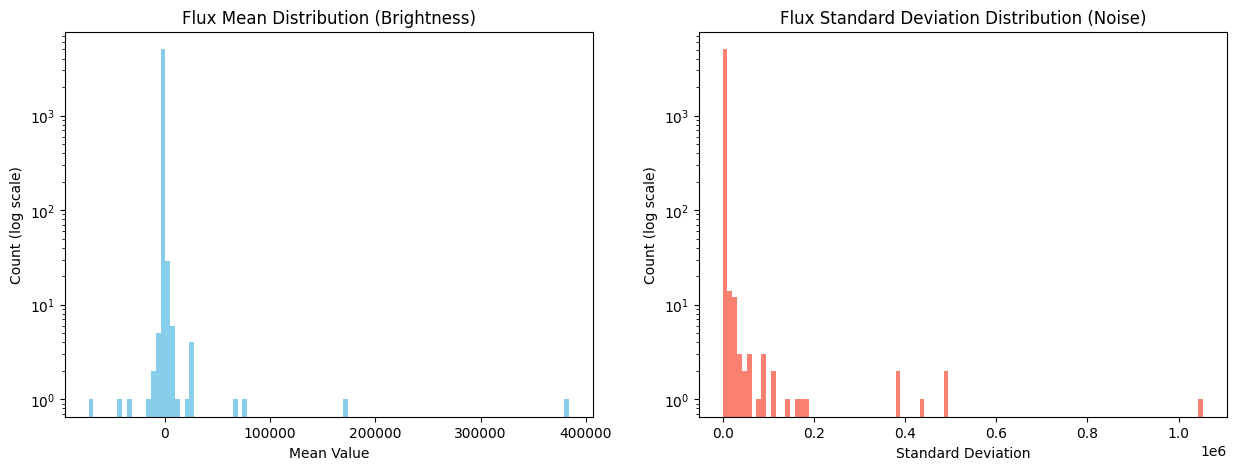

In [3]:
import matplotlib.pyplot as plt

flux_data = train.drop('LABEL', axis=1)
means = flux_data.mean(axis=1)
stds = flux_data.std(axis=1)

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.hist(means, bins=100, color='skyblue')
plt.yscale('log')
plt.title('Flux Mean Distribution (Brightness)')
plt.xlabel('Mean Value')
plt.ylabel('Count (log scale)')

plt.subplot(1, 2, 2)
plt.hist(stds, bins=100, color='salmon')
plt.yscale('log')
plt.title('Flux Standard Deviation Distribution (Noise)')
plt.xlabel('Standard Deviation')
plt.ylabel('Count (log scale)')

plt.show()


### Valorile obținute apelând funcția **.describe() nu prezintă corelații fizice.** Fiecare linie din fișierul .csv reprezintă o stea diferită. Media valorilor pentru coloana FLUX.i, reprezintă media intensității luminoase a tuturor stelelor studiate la momentul ti. Nu există corelație între strălucirea acestor stele. **În setul de date corelația apare doar în cazul linilor.** Fiecare linie din tabel descrie strălucirea stelei la diferite momente de timp.

In [4]:
train.describe()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,...,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.007273,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,...,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,0.084982,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,...,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,1.000000,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,...,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,1.000000,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,...,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,1.000000,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,...,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,1.000000,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,...,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,2.000000,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,...,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


În continuare, am calculat deviația standard a fluxului luminos pentru fiecare stea din setul de date. Au fost identificate primele 100 de stele cu cea mai mare deviație standard. **Dintre aceste 100 de stele, doar una este etichetată ca având o exoplanetă.**

Această observație sugerează că prezența unei exoplanete nu produce, în general, variații mari ale fluxului luminos al stelei. Rezultatul este în concordanță cu modelul matematic prezentat în secțiunile anterioare, conform căruia tranzitul unei planete produce doar o mică scădere a luminozității stelei față de valoarea sa medie.

**Prin urmare, majoritatea fluctuațiilor observate în curbele de lumină sunt cauzate de variabilitatea intrinsecă a stelei sau de erori și zgomot apărute în procesul de măsurare.** Doar o parte foarte mică dintre aceste fluctuații sunt generate de prezența unei exoplanete.

În consecință, modelele de Machine Learning utilizate pentru detecția exoplanetelor trebuie să se concentreze asupra identificării modelelor specifice de tranzit în curbele de lumină, și nu doar asupra amplitudinii variațiilor fluxului luminos.

In [5]:
std_df = train[['LABEL']].copy()
std_df['std'] = stds
top100 = std_df.sort_values(by='std', ascending=False).head(100)
top100['LABEL'].value_counts()


,count
LABEL,
1,99
2,1


### Cele 5 stele cu cea mai mare deviație standard a fluxului

In [6]:
top100.head()

,LABEL,std
778,1,1.053407e+06
3340,1,4.919450e+05
4186,1,4.865408e+05
497,1,4.417071e+05
954,1,3.857630e+05


**X_train** - datele de antremanent filtrate.


**X_test**  - datele de test filtrate.

## Autocorelația în seriile temporale

**Autocorelația** măsoară gradul de corelație dintre valorile unei serii temporale și aceleași valori deplasate în timp (*lags*). În analiza fluxului luminos al stelelor, aceasta ajută la identificarea **tiparelor periodice** care pot indica prezența unei exoplanete.

Autocorelația pentru un decalaj $k$ este definită astfel:

$$
r_k = \frac{\sum_{t=1}^{n-k} (x_t - \bar{x})(x_{t+k} - \bar{x})}{\sum_{t=1}^{n} (x_t - \bar{x})^2}
$$

unde:

* $x_t$ – valoarea seriei la momentul $t$
* $\bar{x}$ – media seriei
* $k$ – decalajul (*lag*)
* $n$ – numărul total de observații

### Interpretarea valorilor

* $r_k$ **mare și pozitiv** → există un tipar repetitiv în serie
* $r_k$ **aproape de zero** → nu există corelație semnificativă
* **vârfuri periodice** în graficul autocorelației → posibilă periodicitate în semnal (de exemplu tranzitul unei exoplanete)


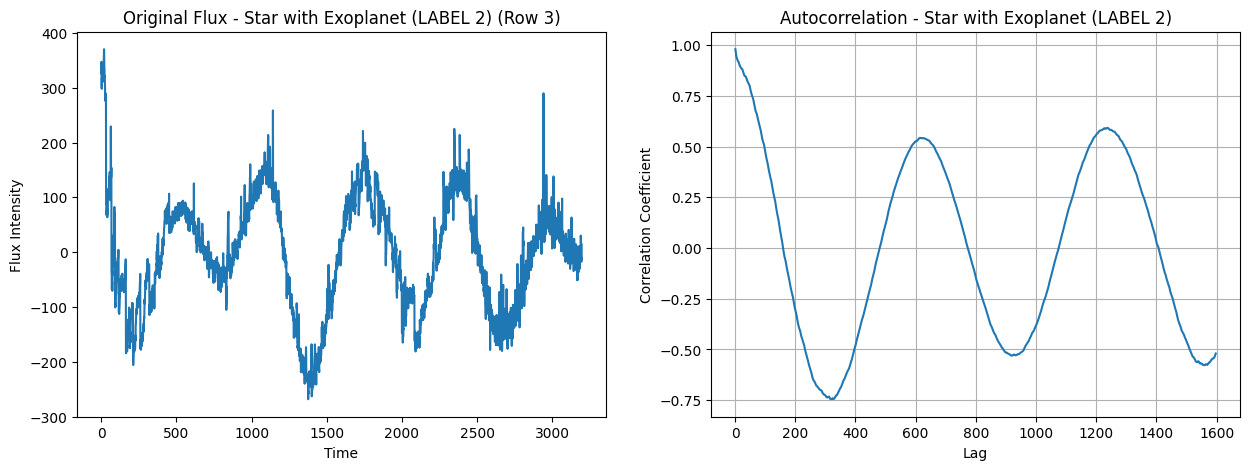

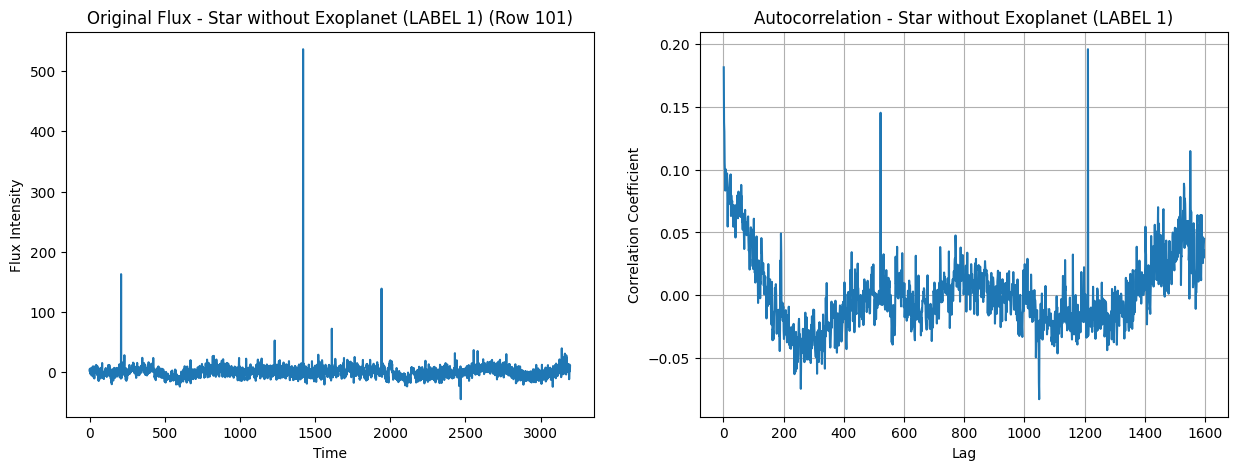

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def plot_autocorrelation(data, row_index, title):

    flux = data.iloc[row_index, 1:]


    flux_normalized = (flux - flux.mean()) / flux.std()

    plt.figure(figsize=(15, 5))


    plt.subplot(1, 2, 1)
    plt.plot(flux.values)
    plt.title(f"Original Flux - {title} (Row {row_index})")
    plt.xlabel("Time")
    plt.ylabel("Flux Intensity")


    plt.subplot(1, 2, 2)

    lags = np.arange(1, len(flux_normalized) // 2)
    autocorr = [flux_normalized.autocorr(lag=l) for l in lags]

    plt.plot(lags, autocorr)
    plt.title(f"Autocorrelation - {title}")
    plt.xlabel("Lag")
    plt.ylabel("Correlation Coefficient")
    plt.grid(True)
    plt.show()


plot_autocorrelation(train[train["LABEL"] == 2], 3, "Star with Exoplanet (LABEL 2)")
plot_autocorrelation(train[train["LABEL"] == 1], 101, "Star without Exoplanet (LABEL 1)")

### Privind graficul de mai sus, am putea presupune că periodicitatea fluxului stelei studiate se datorează tranzitului unei exoplanete. Totuși, această afirmație nu este întotdeauna adevărată. Tranzitul unei exoplanete produce, în general, o variație relativ mică a fluxului luminos al stelei, de aproximativ 1% în cazul planetelor mari de tip Jupiter fierbinte. Dacă într-adevăr ar exista o exoplanetă care orbitează în jurul stelei, acest fenomen ar produce o modificare foarte mică a fluxului, mult mai mică decât variațiile observate în setul de date analizat.

### Există însă mai multe fenomene fizice care pot produce variații ale fluxului stelar. Un exemplu îl reprezintă petele stelare. Stelele au câmpuri magnetice puternice, iar în anumite regiuni aceste câmpuri pot inhiba circulația gazului fierbinte din interiorul stelei. Ca urmare, acele zone devin mai reci și emit mai puțină lumină decât restul suprafeței stelare.

### O altă posibilă cauză a variațiilor fluxului o reprezintă pulsatiile stelare. Unele stele se pot dilata și contracta periodic datorită proceselor fizice care au loc în interiorul lor. Atunci când steaua se extinde, temperatura suprafeței scade, iar fluxul luminos observat scade. În schimb, atunci când steaua se contractă, temperatura crește și fluxul luminos devine mai mare. Acest proces poate produce variații regulate ale luminozității.

### De asemenea, stelele pot produce erupții energetice (stellar flares) cauzate de activitatea câmpului magnetic. Atunci când liniile câmpului magnetic se reorganizează brusc, o cantitate mare de energie este eliberată într-un timp foarte scurt, ceea ce produce o creștere rapidă a luminozității observate.

### În unele cazuri, o stea poate face parte dintr-un sistem stelar binar. Dacă una dintre stele trece periodic prin fața celeilalte, fluxul total observat scade temporar. Acest fenomen poate produce variații periodice foarte clare ale luminozității, care pot semăna cu tranzitul unei planete.

###Din aceste motive, detectarea exoplanetelor este un proces complex, deoarece variațiile fluxului luminos pot avea multiple cauze fizice. Pentru a identifica corect prezența unei exoplanete, este necesară analiza atentă a datelor și utilizarea unor metode statistice și algoritmi de învățare automată.

##**Preprocesarea datelor**

###Datele provenite de la telescopul Kepler sunt preprocesate înainte de aplicarea algoritmilor de Machine Learning. Pentru fiecare stea din fișierul .csv, valorile de flux nu reprezintă valori absolute ale luminozității, ci variația fluxului în raport cu fluxul mediu al stelei. Astfel, algoritmii nu învață amplitudinea absolută a fluxului, ci variațiile fluxului în jurul valorii medii, ceea ce permite detectarea scăderilor periodice ale luminozității cauzate de tranzitul unei exoplanete.

###În plus, valorile sunt standardizate folosind StandardScaler, astfel încât fiecare caracteristică are media 0 și deviația standard 1. Această transformare ajută algoritmii de învățare automată să funcționeze mai stabil și să trateze toate caracteristicile pe aceeași scară.

###Setul de date este puternic dezechilibrat: există 5050 de stele fără exoplanetă și doar 37 de stele cu exoplanetă. În această situație, un algoritm de clasificare ar putea învăța să prezică predominant clasa majoritară (stele fără planetă), obținând o acuratețe aparent ridicată, dar fără a detecta corect exoplanetele.

###Pentru a echilibra setul de date se utilizează tehnica SMOTE (Synthetic Minority Over-sampling Technique). Această metodă generează exemple sintetice pentru clasa minoritară prin interpolare liniară între exemple existente. Fiecare stea din clasa minoritară este reprezentată printr-un vector de aproximativ 3197 valori de flux. Pentru fiecare astfel de stea, algoritmul identifică k = 5 vecini apropiați din aceeași clasă. Apoi este selectat aleator unul dintre acești vecini și se realizează o interpolare liniară între cei doi vectori. Rezultatul este un nou exemplu sintetic, similar cu cele două stele inițiale. Procesul este repetat până când distribuția celor două clase devine echilibrată.

## Tehnica SMOTE

Pentru echilibrarea setului de date folosim metoda **SMOTE (Synthetic Minority Over-sampling Technique)**.  
Această metodă generează exemple sintetice pentru clasa minoritară prin **interpolare liniară** între exemple existente.

Formula utilizată pentru generarea unui exemplu sintetic este:

$$
x_{new} = x_i + \lambda (x_{nn} - x_i)
$$

unde:

- $x_i$ = un exemplu din clasa minoritară  
- $x_{nn}$ = unul dintre vecinii apropiați ai lui $x_i$  
- $\lambda \in [0,1]$ = număr aleator  
- $x_{new}$ = noul exemplu sintetic

---

## Exemplu de interpolare

Considerăm doi vectori care reprezintă fluxul luminos pentru două stele:

$$
x_i = (2,4,6)
$$

$$
x_{nn} = (4,6,8)
$$

Presupunem că valoarea aleatoare este:

$$
\lambda = 0.5
$$

Aplicăm formula SMOTE:

$$
x_{new} = x_i + \lambda (x_{nn} - x_i)
$$

Calculăm diferența dintre vectori:

$$
x_{nn} - x_i = (4,6,8) - (2,4,6) = (2,2,2)
$$

Înmulțim cu $\lambda$:

$$
0.5 \cdot (2,2,2) = (1,1,1)
$$

Adăugăm rezultatul la vectorul inițial:

$$
x_{new} = (2,4,6) + (1,1,1)
$$

Rezultă noul vector sintetic:

$$
x_{new} = (3,5,7)
$$

Acest vector reprezintă un exemplu sintetic situat între cei doi vectori inițiali.

Initial shape: (5087, 3198)

Missing values per column (total): 0

Class distribution before relabeling: {1: 5050, 2: 37}
Class distribution ready for model: {0: 5050, 1: 37}


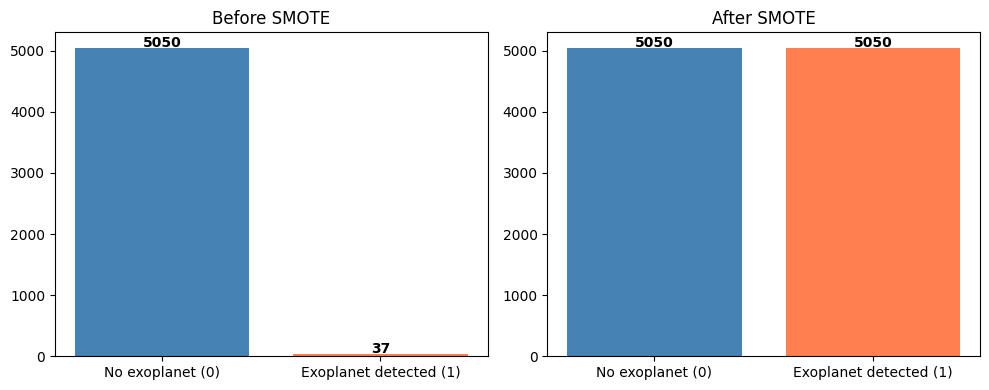


── FINAL PREPROCESSING RESULT ─────────────────────────
X_train (for training): (10100, 3197)
y_train (for training): (10100,)


In [8]:
# pre-processing data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter


df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/exoTrain.csv")
print("Initial shape:", df.shape)


print("\nMissing values per column (total):", df.isnull().sum().sum())


print("\nClass distribution before relabeling:", df["LABEL"].value_counts().to_dict())

if 2 in df["LABEL"].values:
    df["LABEL"] = df["LABEL"].map({1: 0, 2: 1})
print("Class distribution ready for model:", df["LABEL"].value_counts().to_dict())

# X - features, y - target
X = df.drop(columns=["LABEL"]).values
y = df["LABEL"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
labels = ['No exoplanet (0)', 'Exoplanet detected (1)']
counts_before = [Counter(y)[0], Counter(y)[1]]
plt.bar(labels, counts_before, color=['steelblue', 'coral'])
plt.title('Before SMOTE')
for i, v in enumerate(counts_before):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')


smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_scaled, y)

plt.subplot(1, 2, 2)
counts_after = [Counter(y_train)[0], Counter(y_train)[1]]
plt.bar(labels, counts_after, color=['steelblue', 'coral'])
plt.title('After SMOTE')
for i, v in enumerate(counts_after):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()



print(f"\n── FINAL PREPROCESSING RESULT ─────────────────────────")
print(f"X_train (for training): {X_train.shape}")
print(f"y_train (for training): {y_train.shape}")

In [18]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
from collections import Counter

df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/exoTest.csv")
print("exoTest shape:", df_test.shape)
print("\nFirst rows:\n", df_test.head())
print("\nMissing values:", df_test.isnull().sum().sum())

# 1 -> 0, 2 -> 1
print("\nClass distribution before:", df_test["LABEL"].value_counts().to_dict())
df_test["LABEL"] = df_test["LABEL"].map({1: 0, 2: 1})
print("Class distribution after: ", df_test["LABEL"].value_counts().to_dict())


X_external_test = df_test.drop(columns=["LABEL"]).values
y_external_test = df_test["LABEL"].values


X_external_test_scaled = scaler.transform(X_external_test)

print(f"\nX_external_test shape: {X_external_test_scaled.shape}")
print(f"Class 0 (no exoplanet): {Counter(y_external_test)[0]}")
print(f"Class 1 (exoplanet detected): {Counter(y_external_test)[1]}")

exoTest shape: (570, 3198)

First rows:
    LABEL   FLUX.1   FLUX.2   FLUX.3   FLUX.4  ...  FLUX.3193  FLUX.3194  \
0      2   119.88   100.21    86.46    48.68  ...      45.50      31.93   
1      2  5736.59  5699.98  5717.16  5692.73  ...   -2061.17   -2265.98   
2      2   844.48   817.49   770.07   675.01  ...    -174.54     -95.23   
3      2  -826.00  -827.31  -846.12  -836.03  ...      20.75      20.25   
4      2   -39.57   -15.88    -9.16    -6.37  ...     -85.34     -81.46   

   FLUX.3195  FLUX.3196  FLUX.3197  
0      35.78     269.43      57.72  
1   -2366.19   -2294.86   -2034.72  
2    -162.68     -36.79      30.63  
3    -120.81    -257.56    -215.41  
4     -61.98     -69.34     -17.84  

[5 rows x 3198 columns]

Missing values: 0

Class distribution before: {1: 565, 2: 5}
Class distribution after:  {0: 565, 1: 5}

X_external_test shape: (570, 3197)
Class 0 (no exoplanet): 565
Class 1 (exoplanet detected): 5


# **Random Forest**

Random Forest este un algoritm de **ensemble learning** care combină mai mulți arbori de decizie pentru a îmbunătăți performanța predicției. Ideea principală este că, în loc să folosim un singur arbore de decizie, construim un număr mare de arbori independenți și combinăm rezultatele lor prin **vot majoritar** (pentru clasificare) sau **medie** (pentru regresie). Fiecare arbore este antrenat pe un subset diferit de date obținut prin **bootstrap sampling**, iar la fiecare nod se selectează aleator un subset de caracteristici pentru a determina împărțirea optimă.

Conform lucrării lui Breiman (2001), un Random Forest este definit ca o colecție de clasificatori de tip arbore:

$$
\{h(x,\Theta_k), \; k = 1,2,\dots\}
$$

unde $\Theta_k$ este un vector aleator care controlează modul în care este construit arborele $k$, iar $h(x,\Theta_k)$ reprezintă predicția arborelui pentru un exemplu $x$.

Predicția finală este obținută prin votul arborilor din pădure.

---

# Funcția de margine (Margin Function)

Pentru a evalua performanța Random Forest, Breiman introduce **funcția de margine**:

$$
mg(X,Y) = \text{avg}_k \, I(h_k(X)=Y) - \max_{j \ne Y} \text{avg}_k \, I(h_k(X)=j)
$$

unde:

- $I(\cdot)$ este funcția indicator
- $h_k(X)$ este predicția arborelui $k$
- $Y$ este clasa reală

Această funcție măsoară diferența dintre voturile pentru clasa corectă și voturile pentru cea mai probabilă clasă greșită. O margine mare indică o clasificare mai sigură.

---

# Eroarea de generalizare

Eroarea de generalizare a unui Random Forest este definită ca probabilitatea ca marginea să fie negativă:

$$
PE^* = P_{X,Y}(mg(X,Y) < 0)
$$

Aceasta reprezintă probabilitatea ca modelul să clasifice greșit un exemplu.

---

# Strength și Correlation

Performanța Random Forest depinde de două proprietăți fundamentale:

- **strength (s)** – cât de buni sunt arborii individuali
- **correlation ($\rho$)** – cât de corelate sunt erorile dintre arbori

Breiman arată că eroarea de generalizare poate fi limitată prin relația:

$$
PE^* \leq \frac{\rho(1-s^2)}{s^2}
$$

Această formulă arată că performanța modelului este mai bună atunci când:

- arborii sunt **puternici** (strength mare)
- arborii sunt **puțin corelați** între ei.

Selecția aleatorie a caracteristicilor la fiecare nod reduce corelația dintre arbori și contribuie la îmbunătățirea performanței.

---

# Interpretarea rezultatelor experimentului

Modelul Random Forest a fost antrenat folosind `class_weight='balanced'` pentru a compensa dezechilibrul dintre clase. După antrenare, s-a aplicat un prag de probabilitate de **0.30** pentru clasificare.

Rezultatele obținute au fost:

- **Accuracy:** 0.9912  
- **Precision:** 0.0000  
- **Recall:** 0.0000  
- **F1-score:** 0.0000  

Matricea de confuzie:

Aceste rezultate arată că modelul a prezis **doar clasa majoritară ("Fără")**. Deși acuratețea este foarte mare (99%), aceasta este înșelătoare deoarece setul de date este **puternic dezechilibrat**. Modelul nu a detectat niciun caz pozitiv, ceea ce duce la valori zero pentru precision, recall și F1-score.

Această situație apare frecvent în probleme cu **date dezechilibrate**, unde modelul învață să prezică doar clasa majoritară pentru a maximiza acuratețea. Pentru astfel de probleme este recomandat să se analizeze metrici precum **recall**, **F1-score** sau **ROC-AUC**, precum și să se utilizeze tehnici de reechilibrare a datelor (de exemplu **oversampling sau SMOTE**).

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

print("Training Random Forest with class_weight='balanced'...")
rf_model_adjusted = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)
rf_model_adjusted.fit(X_train, y_train)


print("Computing prediction probabilities...")

y_probs = rf_model_adjusted.predict_proba(X_external_test_scaled)[:, 1]


THRESHOLD = 0.12
print(f"\nApplying threshold of {THRESHOLD * 100}%...")
y_pred_adjusted = (y_probs >= THRESHOLD).astype(int)


accuracy_adj = accuracy_score(y_external_test, y_pred_adjusted)
precision_adj = precision_score(y_external_test, y_pred_adjusted, zero_division=0)
recall_adj = recall_score(y_external_test, y_pred_adjusted, zero_division=0)
f1_adj = f1_score(y_external_test, y_pred_adjusted, zero_division=0)

print("\n── RESULTS WITH ADJUSTED THRESHOLD ───────────────────────")
print(f"Accuracy:  {accuracy_adj:.4f}")
print(f"Precision: {precision_adj:.4f}")
print(f"Recall:    {recall_adj:.4f}")
print(f"F1-Score:  {f1_adj:.4f}")

cm_adj = confusion_matrix(y_external_test, y_pred_adjusted)
print("\nConfusion Matrix (Threshold 0.12):")
print(f"TN [No -> Predicted No]: {cm_adj[0, 0]}")
print(f"FP [No -> Predicted Yes]: {cm_adj[0, 1]}")
print(f"FN [Yes -> Predicted No]: {cm_adj[1, 0]}")
print(f"TP [Yes -> Predicted Yes]: {cm_adj[1, 1]}")

Training Random Forest with class_weight='balanced'...
Computing prediction probabilities...

Applying threshold of 12.0%...

── RESULTS WITH ADJUSTED THRESHOLD ───────────────────────
Accuracy:  0.8930
Precision: 0.0484
Recall:    0.6000
F1-Score:  0.0896

Confusion Matrix (Threshold 0.12):
TN [No -> Predicted No]: 506
FP [No -> Predicted Yes]: 59
FN [Yes -> Predicted No]: 2
TP [Yes -> Predicted Yes]: 3


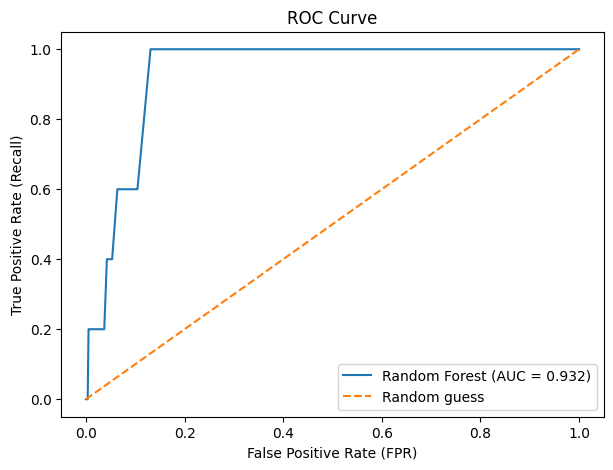

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score


fpr, tpr, thresholds = roc_curve(y_external_test, y_probs)

roc_auc = roc_auc_score(y_external_test, y_probs)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], linestyle="--", label="Random guess")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Clasificatorul k-Nearest Neighbours

În cadrul acestui proiect vom folosi clasificatorul **k-Nearest Neighbours (kNN)**. Acest clasificator este util în special atunci când lucrăm cu seturi de date care conțin un număr mare de eșantioane. Algoritmul kNN aparține domeniului **Statisticii Neparametrice**, o ramură a statisticii în care nu se presupune cunoașterea distribuției de probabilitate a datelor.

Regula **Nearest Neighbour (NN)** pentru clasificarea datelor constă în faptul că, pentru a atribui o categorie unui element necunoscut $x$, se caută punctul din setul de antrenament care se află la **distanța minimă** față de acesta. Distanța este calculată într-un **spațiu metric**, folosind o funcție de distanță $d(x_i, x)$.

Formal, cel mai apropiat vecin $x_j$ al punctului $x$ este definit prin relația:

$$
x_j = \arg\min_{i} d(x_i, x)
$$

După identificarea vecinului cel mai apropiat, punctului $x$ i se atribuie aceeași categorie ca și acestui vecin.

În cazul nostru, pentru fiecare stea din **setul de test**, se caută cea mai apropiată stea din **setul de antrenament**, adică steaua pentru care variația fluxului este cea mai asemănătoare. Stelei din setul de test i se atribuie eticheta vecinului cel mai apropiat din setul de antrenament.

Pentru ca algoritmul să funcționeze corect, valorile utilizate trebuie să aparțină unui **spațiu metric**, deoarece clasificarea se bazează pe calculul distanțelor dintre eșantioane. Alegerea metricii este foarte importantă, deoarece aceasta influențează performanța clasificatorului.

---

## Generalizarea regulii NN

Regula **k-Nearest Neighbours (kNN)** reprezintă o generalizare a regulii NN. În loc să folosim un singur vecin, algoritmul selectează **cei mai apropiați $k$ vecini** ai punctului analizat.

Clasa punctului $x$ este determinată prin **vot majoritar** dintre clasele celor $k$ vecini.

Dacă notăm cu $C_i$ clasele vecinilor selectați, atunci clasa atribuită punctului $x$ este:

$$
C(x) = \text{majority}(C_1, C_2, ..., C_k)
$$

---

## Alegerea parametrului $k$

Alegerea valorii parametrului $k$ influențează performanța algoritmului.

- Dacă $k$ este **mic**, vecinii selectați vor fi foarte asemănători cu elementul analizat, însă clasificarea poate deveni sensibilă la zgomot sau la variații locale ale datelor.
- Dacă $k$ este **mare**, clasificarea devine mai stabilă, dar pot fi incluși vecini care nu sunt foarte asemănători cu punctul analizat.

În general:
- $k$ mic → model sensibil la zgomot (overfitting)
- $k$ mare → model prea general (underfitting)

---

## Performanța clasificatorului NN

Conform rezultatelor teoretice prezentate în articolul lui Cover și Hart, eroarea clasificatorului **Nearest Neighbour** satisface relația:

$$
R^* \leq R \leq 2R^*(1 - R^*)
$$

unde:

- $R^*$ reprezintă **eroarea Bayes**, adică eroarea minimă posibilă pentru problema de clasificare.
- $R$ reprezintă **eroarea clasificatorului Nearest Neighbour**.

Dacă valoarea lui $R^*$ este foarte mică, atunci aproximativ:

$$
R \approx 2R^*
$$

Acest rezultat arată că performanța clasificatorului NN este foarte apropiată de cea a clasificatorului Bayes optim. În consecință, se poate spune că aproximativ **jumătate din informația de clasificare disponibilă într-un set infinit de date este conținută în cel mai apropiat vecin**.





## Referință

Conceptele teoretice prezentate mai sus, precum regula **Nearest Neighbour**, clasificatorul **k-Nearest Neighbours** și relația dintre eroarea clasificatorului NN și **eroarea Bayes**, sunt bazate pe rezultatele prezentate în articolul:

T. M. Cover și P. E. Hart,  
**"Nearest Neighbor Pattern Classification"**,  

In [20]:
from sklearn.neighbors import KNeighborsClassifier

print("Training KNN model...")

knn_model = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)


knn_model.fit(X_train, y_train)
print("Training complete!")

print("\nGenerating predictions on exoTest.csv...")
y_pred_knn = knn_model.predict(X_external_test_scaled)


accuracy_knn = accuracy_score(y_external_test, y_pred_knn)
precision_knn = precision_score(y_external_test, y_pred_knn, zero_division=0)
recall_knn = recall_score(y_external_test, y_pred_knn, zero_division=0)
f1_knn = f1_score(y_external_test, y_pred_knn, zero_division=0)

print("\n── KNN RESULTS ───────────────────────────────────────")
print(f"Accuracy:  {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1-Score:  {f1_knn:.4f}")

cm_knn = confusion_matrix(y_external_test, y_pred_knn)
print("\nKNN Confusion Matrix:")
print(f"TN [No -> Predicted No]: {cm_knn[0, 0]}")
print(f"FP [No -> Predicted Yes]: {cm_knn[0, 1]}")
print(f"FN [Yes -> Predicted No]: {cm_knn[1, 0]}")
print(f"TP [Yes -> Predicted Yes]: {cm_knn[1, 1]}")

Training KNN model...
Training complete!

Generating predictions on exoTest.csv...

── KNN RESULTS ───────────────────────────────────────
Accuracy:  0.9895
Precision: 0.3333
Recall:    0.2000
F1-Score:  0.2500

KNN Confusion Matrix:
TN [No -> Predicted No]: 563
FP [No -> Predicted Yes]: 2
FN [Yes -> Predicted No]: 4
TP [Yes -> Predicted Yes]: 1


## Un studiu de caz: când semnalele candidate de exoplanete sunt de fapt pulsații stelare

Detectarea exoplanetelor din curbe de lumină nu este întotdeauna un proces simplu. Chiar dacă în date apar semnale periodice, acestea pot avea mai multe explicații fizice. Un exemplu foarte bun al acestei complexități este analiza a două stele observate de telescopul spațial **Kepler**: **KIC 5807616** și **KIC 10001893**.

Inițial, astronomii au detectat în transformata Fourier a curbelor de lumină ale acestor stele **semnale de frecvență joasă**, în jur de aproximativ **48 μHz**, **33 μHz** și **14 μHz**. Deoarece aceste semnale erau periodice și nu păreau să provină din pulsațiile stelare cunoscute, ele au fost interpretate inițial ca posibile semnături ale unor **exoplanete aflate pe orbite foarte apropiate de stele**.

Ideea era următoarea: o planetă foarte apropiată de stea poate reflecta sau reemite radiația stelară. Pe măsură ce planeta se deplasează pe orbită, cantitatea de lumină observată variază periodic. Această variație produce un semnal aproape sinusoidal în curba de lumină, cu o frecvență egală cu frecvența orbitală a planetei.

Totuși, o analiză mai detaliată a arătat că lucrurile sunt mai complicate.

### Rolul pulsațiilor stelare

Stelele analizate sunt **subdwarfi B (sdB)**, un tip de stele care prezintă **pulsații stelare**, în special moduri de tip **g-mode (gravity modes)**. Atunci când mai multe moduri de pulsație sunt prezente simultan, interacțiunile neliniare dintre ele pot produce **frecvențe de combinație**, de forma:

$$
f_i - f_j \quad \text{și} \quad f_i + f_j
$$

Aceste frecvențe pot apărea în spectrul Fourier chiar dacă ele nu corespund unui mod fizic independent.

Când cercetătorii au analizat toate combinațiile posibile dintre frecvențele modurilor de pulsație ale stelei, au descoperit că semnalele suspecte pot fi reproduse foarte bine ca **diferențe între moduri de pulsație existente**. Cu alte cuvinte, semnalele nu necesitau existența unor planete pentru a fi explicate.

### Probleme instrumentale și observaționale

Analiza a fost complicată și de alți factori observaționali:

- **artefacte instrumentale** în datele Kepler, care apar în special la frecvențe joase (de exemplu în jur de **3.8 μHz**);
- **contaminarea luminii** provenite de la stele vecine, care poate modifica amplitudinile semnalelor;
- amplitudini foarte mici ale variațiilor de flux, de ordinul **zeci de părți per milion (ppm)**.

Pentru a reduce aceste efecte, autorii au folosit o **stea de comparație** și au analizat modul în care se modifică semnalele după corecția artefactelor instrumentale.

### Testul stabilității frecvenței

Un alt test important a fost verificarea **stabilității frecvenței semnalelor în timp**. Dacă semnalul ar proveni de la o planetă pe orbită stabilă, frecvența ar trebui să rămână aproape constantă pe toată durata observațiilor.

Simulările au arătat că un semnal planetar ar trebui să rămână într-un interval de aproximativ:
$$
\pm 0.03 \, \mu Hz
$$

față de frecvența inițială. În schimb, unele dintre semnalele observate în date variau mult mai mult decât această limită, ceea ce sugerează o origine **stelară**, nu planetară.

### Lecții pentru detectarea exoplanetelor

Acest studiu de caz arată un lucru esențial în astronomia exoplanetelor:

> Nu orice semnal periodic observat într-o curba de lumină provine de la o planetă.

Astronomii trebuie să ia în considerare mai multe explicații alternative, precum:

- pulsații stelare
- combinații neliniare între moduri de pulsație
- artefacte instrumentale
- contaminarea luminii de la stele vecine

Abia după eliminarea acestor posibilități se poate concluziona că un semnal este produs de o exoplanetă.

### Legătura cu Machine Learning

Pentru metodele de **Machine Learning aplicate detectării exoplanetelor**, acest exemplu este foarte important. Modelele trebuie să învețe să distingă între:

- semnale reale produse de tranzitul sau orbita unei planete
- variații produse de activitatea stelei
- zgomot sau artefacte instrumentale

Prin urmare, **preprocesarea datelor și înțelegerea fenomenelor astrofizice** sunt esențiale pentru a construi modele de clasificare robuste și pentru a evita detecțiile false.

**Referință**

Analiza descrisă în această secțiune se bazează pe studiul:

Blokesz, A., Krzesiński, J., & Kędziora-Chudczer, L. (2019).  
**Analysis of putative exoplanetary signatures found in light curves of two sdBV stars observed by Kepler.**

In [21]:
# Fourier Transform

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


print("Applying Fourier Transform (FFT) on light curves...")


X_train_fft = np.abs(np.fft.rfft(X_train, axis=1))
X_test_fft = np.abs(np.fft.rfft(X_external_test_scaled, axis=1))

print(f"Feature dimension reduced from {X_train.shape[1]} (time points) to {X_train_fft.shape[1]} (frequency components).")


print("\nTraining KNN model on frequency spectrum...")
knn_fft_model = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn_fft_model.fit(X_train_fft, y_train)
print("Training complete!")


print("Generating predictions on exoTest dataset (FFT)...")
y_pred_fft = knn_fft_model.predict(X_test_fft)


accuracy_fft = accuracy_score(y_external_test, y_pred_fft)
precision_fft = precision_score(y_external_test, y_pred_fft, zero_division=0)
recall_fft = recall_score(y_external_test, y_pred_fft, zero_division=0)
f1_fft = f1_score(y_external_test, y_pred_fft, zero_division=0)

print("\n── KNN RESULTS (WITH FOURIER) ────────────────────────")
print(f"Accuracy:  {accuracy_fft:.4f}")
print(f"Precision: {precision_fft:.4f}")
print(f"Recall:    {recall_fft:.4f}")
print(f"F1-Score:  {f1_fft:.4f}")


cm_fft = confusion_matrix(y_external_test, y_pred_fft)
print("\nFFT Confusion Matrix:")
print(f"TN [No -> Predicted No]: {cm_fft[0, 0]}")
print(f"FP [No -> Predicted Yes]: {cm_fft[0, 1]}")
print(f"FN [Yes -> Predicted No]: {cm_fft[1, 0]}")
print(f"TP [Yes -> Predicted Yes]: {cm_fft[1, 1]}")

Applying Fourier Transform (FFT) on light curves...
Feature dimension reduced from 3197 (time points) to 1599 (frequency components).

Training KNN model on frequency spectrum...
Training complete!
Generating predictions on exoTest dataset (FFT)...

── KNN RESULTS (WITH FOURIER) ────────────────────────
Accuracy:  0.9842
Precision: 0.1667
Recall:    0.2000
F1-Score:  0.1818

FFT Confusion Matrix:
TN [No -> Predicted No]: 560
FP [No -> Predicted Yes]: 5
FN [Yes -> Predicted No]: 4
TP [Yes -> Predicted Yes]: 1


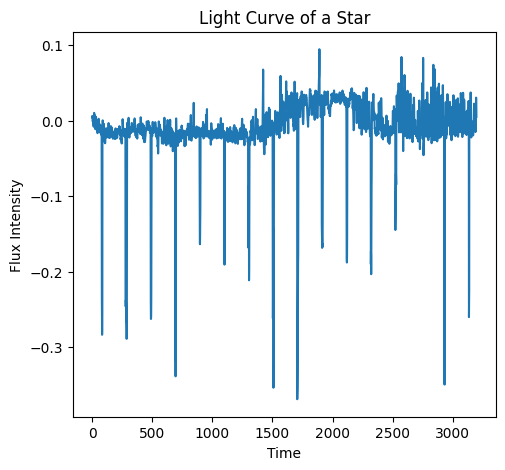

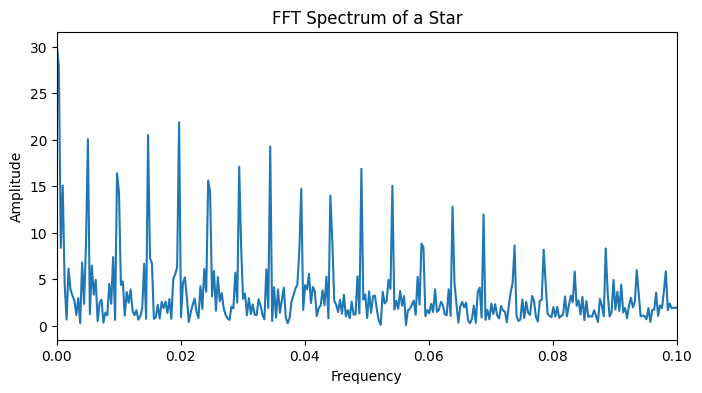

<Figure size 640x480 with 0 Axes>

In [22]:
index = 0

light_curve = X_train[y_train == 1][7]
fft_spectrum = np.abs(np.fft.rfft(light_curve))


freq = np.fft.rfftfreq(len(light_curve))

plt.figure(figsize=(12,5))


plt.subplot(1,2,1)
plt.plot(light_curve)
plt.title("Light Curve of a Star")
plt.xlabel("Time")
plt.ylabel("Flux Intensity")


plt.figure(figsize=(8,4))
plt.plot(freq, fft_spectrum)
plt.xlim(0, 0.1)
plt.title("FFT Spectrum of a Star")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

plt.tight_layout()
plt.show()

## Phase Folding și Binning

### Phase Folding

Phase folding este o metodă utilizată în astronomie pentru procesarea curbelor de lumină ale stelelor. Atunci când o planetă orbitează o stea, apare o scădere periodică a fluxului luminos, numită **tranzit**. Aceste scăderi au o perioadă aproximativ constantă, egală cu perioada orbitală a planetei.

Măsurătorile analizate în această lucrare sunt realizate la intervale de aproximativ **30 de minute**, pe o durată totală de aproximativ **66 de zile**. Exoplanetele pe care încercăm să le detectăm sunt planete de dimensiuni comparabile cu **Jupiter**, care orbitează relativ aproape de steaua gazdă. Aceste planete produc variații mai mari ale fluxului luminos, fiind astfel mai ușor de detectat decât planetele mai mici sau mai îndepărtate.

Deoarece aceste planete sunt apropiate de stea, ele au perioade orbitale de ordinul **câtorva zile**. Astfel, în cadrul observațiilor realizate de telescopul **Kepler**, o planetă poate produce mai multe tranzite, câte unul la fiecare orbită. În consecință, semnalul produs de planetă este înregistrat de mai multe ori, la intervale egale cu perioada orbitală.

Ideea metodei **phase folding** este de a transforma timpul observației într-o **fază orbitală** și de a suprapune toate orbitele într-un singur ciclu.

Faza orbitală este definită prin formula:

$$
\phi = \frac{t \bmod P}{P}
$$

unde:

- $t$ reprezintă momentul observației  
- $P$ reprezintă perioada orbitală  

Prin această transformare, punctele care provin din orbite diferite dar au **aceeași fază orbitală** sunt suprapuse. Ca rezultat, semnalele periodice devin mai pronunțate, iar zgomotul aleator este atenuat.

---

### Binning

După aplicarea **phase folding**, se utilizează tehnica de **binning**, care constă în împărțirea intervalului de fază $[0,1]$ în mai multe intervale egale (numite *bins*).

Pentru fiecare bin se calculează **media fluxului** tuturor punctelor care au faza orbitală în acel interval.

Această procedură are două avantaje importante:

- reduce zgomotul din date prin mediere
- reduce dimensionalitatea datelor

În cadrul acestei lucrări, numărul de coloane a fost redus de la aproximativ **3050** la **100**, fiecare coloană reprezentând fluxul mediu pentru un interval de fază orbitală.

Prin combinarea tehnicilor **phase folding** și **binning**, obținem o **curbă de lumină medie pe o singură orbită**, care evidențiază mai clar semnalele produse de tranzitele exoplanetelor.

In [23]:
# Phase Folding + KNN

import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Applying Phase Folding and Binning to all data...")

def apply_phase_folding(raw_data, period=300, num_bins=100):

    num_stars, num_time_points = raw_data.shape
    folded_data = np.zeros((num_stars, num_bins))

    time = np.arange(num_time_points)
    phase = (time % period) / period
    bin_edges = np.linspace(0, 1, num_bins + 1)

    for i in range(num_stars):
        flux = raw_data[i]
        for b in range(num_bins):

            mask = (phase >= bin_edges[b]) & (phase < bin_edges[b+1])
            if np.sum(mask) > 0:
                folded_data[i, b] = np.mean(flux[mask])
            else:
                folded_data[i, b] = 0

    return folded_data


X_train_folded = apply_phase_folding(X_train, period=230, num_bins=100)
X_test_folded = apply_phase_folding(X_external_test_scaled, period=230, num_bins=100)

print(f"Feature dimension reduced to {X_train_folded.shape[1]} (averaged phase bins).")


print("\nTraining KNN model on folded data...")
knn_pf_model = KNeighborsClassifier(n_neighbors=1, n_jobs=-1)
knn_pf_model.fit(X_train_folded, y_train)
print("Training complete!")


print("Generating predictions on exoTest.csv...")
y_pred_pf = knn_pf_model.predict(X_test_folded)


accuracy_pf = accuracy_score(y_external_test, y_pred_pf)
precision_pf = precision_score(y_external_test, y_pred_pf, zero_division=0)
recall_pf = recall_score(y_external_test, y_pred_pf, zero_division=0)
f1_pf = f1_score(y_external_test, y_pred_pf, zero_division=0)

print("\n── KNN RESULTS (WITH PHASE FOLDING) ────────────────────")
print(f"Accuracy:  {accuracy_pf:.4f}")
print(f"Precision: {precision_pf:.4f}")
print(f"Recall:    {recall_pf:.4f}")
print(f"F1-Score:  {f1_pf:.4f}")


cm_pf = confusion_matrix(y_external_test, y_pred_pf)
print("\nPhase Folding Confusion Matrix:")
print(f"TN [No -> Predicted No]: {cm_pf[0, 0]}")
print(f"FP [No -> Predicted Yes]: {cm_pf[0, 1]}")
print(f"FN [Yes -> Predicted No]: {cm_pf[1, 0]}")
print(f"TP [Yes -> Predicted Yes]: {cm_pf[1, 1]}")

Applying Phase Folding and Binning to all data...
Feature dimension reduced to 100 (averaged phase bins).

Training KNN model on folded data...
Training complete!
Generating predictions on exoTest.csv...

── KNN RESULTS (WITH PHASE FOLDING) ────────────────────
Accuracy:  0.9877
Precision: 0.3750
Recall:    0.6000
F1-Score:  0.4615

Phase Folding Confusion Matrix:
TN [No -> Predicted No]: 560
FP [No -> Predicted Yes]: 5
FN [Yes -> Predicted No]: 2
TP [Yes -> Predicted Yes]: 3


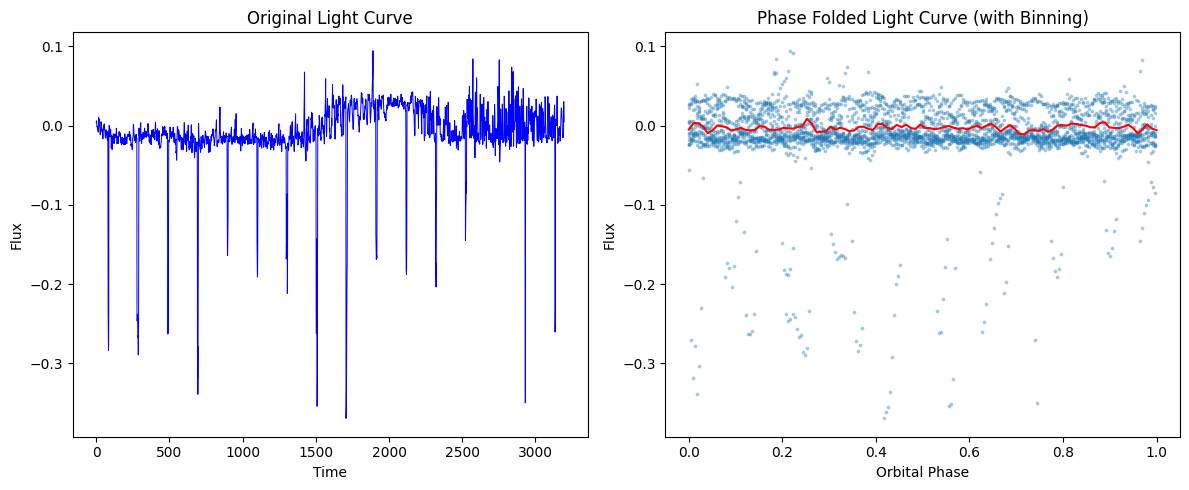

In [16]:
# Select one star from the dataset (example: first star)
star_index = 0

original_flux = X_train[y_train == 1][7]
num_time_points = len(original_flux)
time = np.arange(num_time_points)

# Period used for phase folding
period = 230

# Compute phase
phase = (time % period) / period

# Folded flux (after binning)
folded_flux = X_train_folded[star_index]

# Phase bin centers
num_bins = 100
bin_centers = np.linspace(0, 1, num_bins)

# Create plots
plt.figure(figsize=(12,5))

# Plot 1: Original light curve (before phase folding)
plt.subplot(1,2,1)
plt.plot(time, original_flux, color='blue', linewidth=0.7)
plt.title("Original Light Curve")
plt.xlabel("Time")
plt.ylabel("Flux")

# Plot 2: Phase folded light curve
plt.subplot(1,2,2)
plt.scatter(phase, original_flux, s=3, alpha=0.3)
plt.plot(bin_centers, folded_flux, color='red')
plt.title("Phase Folded Light Curve (with Binning)")
plt.xlabel("Orbital Phase")
plt.ylabel("Flux")

plt.tight_layout()
plt.show()

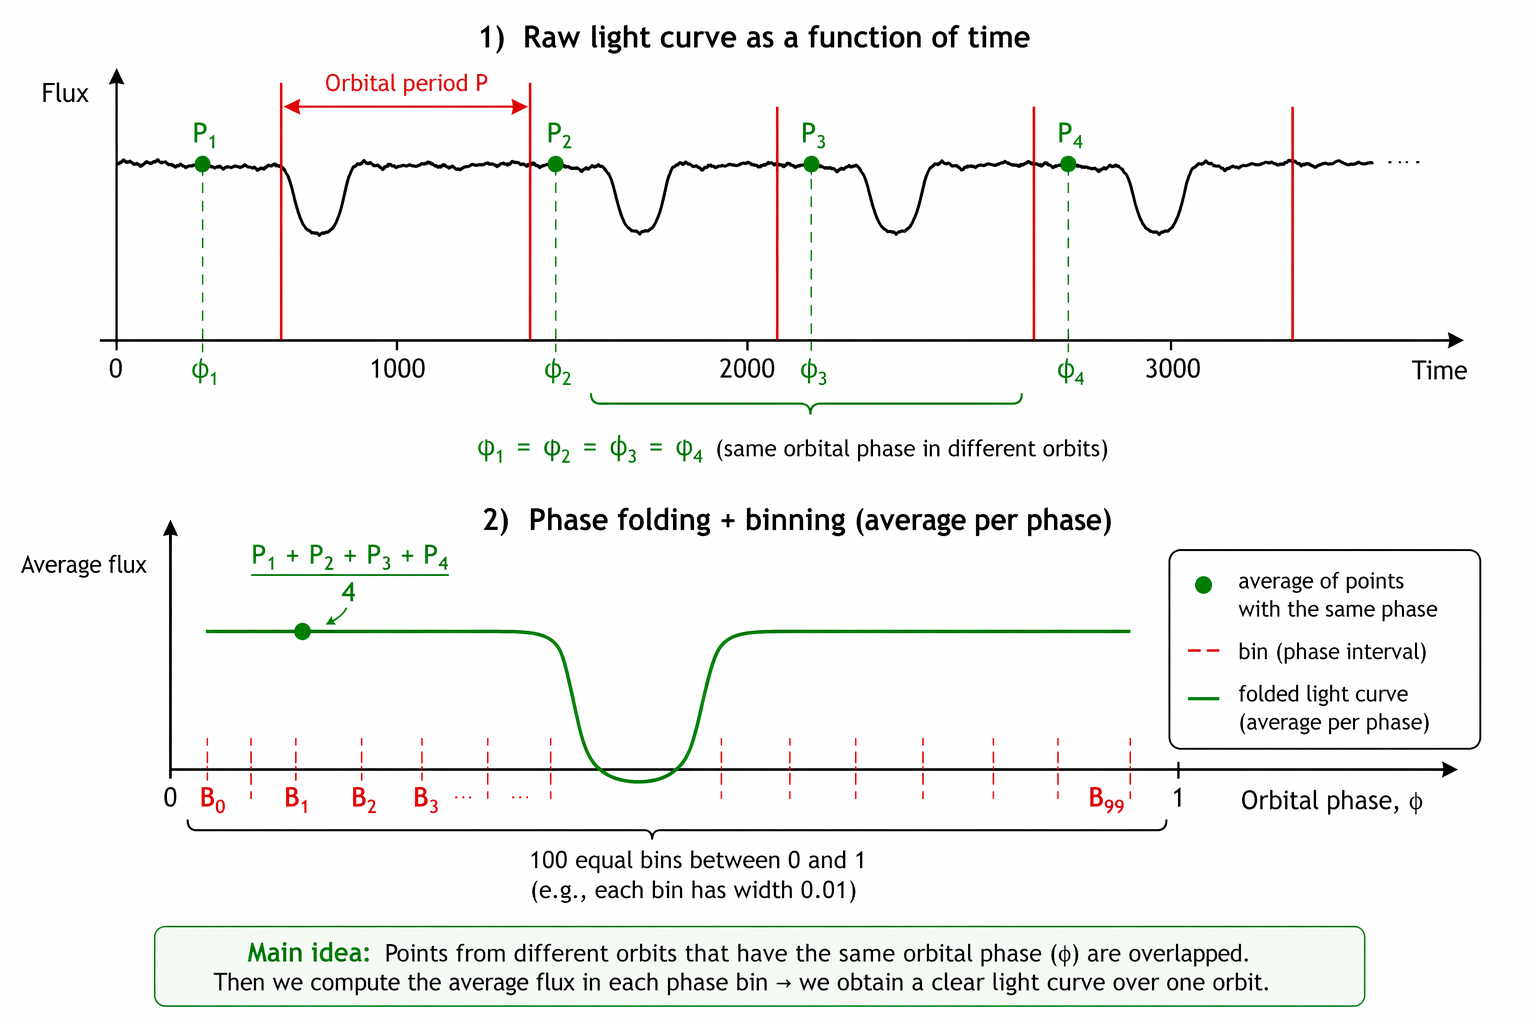

### **Informații adiționale referitaoare la perioada orbitală a planetelor studiate de Kepler Space Telescope.**

### Hot Jupiters și perioadele lor orbitale

Planetele cunoscute sub numele de **Hot Jupiters** sunt exoplanete gazoase cu mase comparabile cu Jupiter, care orbitează foarte aproape de steaua lor gazdă. Din cauza distanței foarte mici față de stea, aceste planete au **perioade orbitale foarte scurte**, de obicei de ordinul **câtorva zile**.

În multe cazuri, distanța față de stea este cuprinsă aproximativ între **0.02 AU și 0.1 AU**.

Pentru comparație:

| Planetă | Distanță față de Soare |
|---|---|
| Mercur | 0.39 AU |
| Jupiter | 5.2 AU |

Hot Jupiters sunt de multe ori **mai aproape de stea decât Mercur de Soare**, ceea ce duce la perioade orbitale foarte mici.

Conform **legii a treia a lui Kepler**:

$$
P^2 \propto a^3
$$

unde:
- $P$ = perioada orbitală  
- $a$ = distanța față de stea  

O distanță orbitală mică implică o **perioadă orbitală scurtă**.

### Exemple de Hot Jupiters

| Planetă | Perioadă orbitală |
|---|---|
| 51 Pegasi b | 4.23 zile |
| HD 209458 b | 3.52 zile |
| WASP-12 b | 1.09 zile |
| WASP-18 b | 0.94 zile |

Datorită acestor perioade scurte, în observațiile realizate de telescopul **Kepler** pe durate de câteva zeci de zile se pot observa **multiple tranzite ale aceleiași planete**.

De exemplu, pentru o planetă cu o perioadă orbitală de aproximativ **3 zile**, într-o perioadă de observație de **66 de zile** pot apărea aproximativ:

$$
66 / 3 \approx 22
$$

tranzite. Acest lucru face ca metodele precum **phase folding** să fie foarte eficiente în evidențierea semnalului produs de exoplanete.


## Discrete Fourier Transform (DFT) și limitele sale

Transformata Fourier discretă (DFT) este o metodă matematică utilizată pentru a analiza periodicitatea unui semnal. În cazul curbelor de lumină stelare, DFT transformă semnalul din domeniul timpului în domeniul frecvenței.

Dacă semnalul luminos este notat cu $x(t)$, atunci transformata Fourier identifică frecvențele periodice care contribuie la formarea acestuia. În forma discretă, transformata Fourier este definită prin relația:

$$
X_k = \sum_{n=0}^{N-1} x_n e^{-i2\pi kn/N}
$$

unde:

- $x_n$ reprezintă valorile semnalului în timp
- $N$ este numărul total de măsurători
- $X_k$ reprezintă amplitudinea frecvenței $k$

Spectrul Fourier arată astfel cât de puternică este fiecare frecvență în semnalul analizat.

---

## Aplicarea transformatei Fourier în detectarea exoplanetelor

Dacă o planetă tranzitează periodic o stea, fluxul luminos prezintă scăderi regulate. Acest fenomen introduce o periodicitate în semnal, care poate fi detectată prin transformata Fourier.

Perioada orbitală $P$ a planetei este legată de frecvența detectată în spectrul Fourier prin relația:

$$
f = \frac{1}{P}
$$

Prin urmare, în spectrul Fourier apare un **peak** la frecvența corespunzătoare perioadei orbitale.

---

## Limitările transformatei Fourier

Deși transformata Fourier este utilă pentru identificarea periodicitaților, ea prezintă mai multe limitări în analiza curbelor de lumină produse de tranzitele exoplanetelor.

### 1. Tranzitul nu este un semnal sinusoidal

Transformata Fourier funcționează cel mai bine pentru semnale sinusoidale. Tranzitele planetare însă au o formă aproximativ dreptunghiulară: |____|.

Un astfel de semnal nu poate fi reprezentat printr-o singură frecvență. Conform teoriei Fourier, el este descompus într-o frecvență fundamentală și mai multe **armonici**:

$$
f, \; 2f, \; 3f, \; 4f, \ldots
$$

Astfel, în spectrul Fourier apar mai multe peak-uri, nu doar unul singur.

---

### 2. Perioade orbitale diferite

Exoplanetele pot avea perioade orbitale diferite. Deoarece frecvența este inversul perioadei:

$$
f = \frac{1}{P}
$$

peak-ul corespunzător planetei va apărea la frecvențe diferite pentru fiecare sistem stelar. Acest lucru face dificilă compararea directă a spectrelor Fourier între diferite stele.

---

### 3. Sensibilitatea la zgomot

Datele observate de telescopul Kepler conțin și variații care nu sunt produse de tranzite, cum ar fi:

- zgomot instrumental
- oscilații stelare
- rotația stelei
- pete stelare

Aceste fenomene pot introduce frecvențe suplimentare în spectrul Fourier, ceea ce face mai dificilă identificarea frecvenței reale a tranzitului.

---

### 4. Prezența armonicilor

Deoarece forma tranzitului nu este sinusoidală, spectrul Fourier conține frecvența fundamentală și armonici ale acesteia. În unele cazuri, armonicile pot avea amplitudini comparabile cu frecvența principală, ceea ce poate complica interpretarea spectrului.

---

Transformata Fourier este un instrument util pentru identificarea periodicitaților în curbele de lumină stelare. Totuși, în cazul tranzitelor exoplanetare, forma nesinusoidală a semnalului, variațiile stelare și zgomotul instrumental pot produce spectre complexe, cu multiple frecvențe și armonici. Din acest motiv, transformata Fourier este adesea combinată cu alte metode, precum **phase folding** sau **Box Least Squares (BLS)**, care sunt mai potrivite pentru detectarea tranzitelor planetare.


## **Concluzie**
Detectarea exoplanetelor pe baza curbelor de lumină este dificilă din cauza variațiilor intrinseci ale stelelor, care maschează semnalul slab al tranzitului planetar. Aplicarea unor tehnici de procesare a semnalului, precum Fourier Transform și Phase Folding, permite evidențierea componentelor periodice relevante.

Dintre metodele testate, combinația Phase Folding + kNN a oferit cele mai bune rezultate în reducerea falsurilor pozitive. Pe un set dezechilibrat (570 stele, dintre care 5 cu planetă), modelul a detectat 3 exoplanete și a generat 5 falsuri pozitive.

Deși precizia rămâne limitată, metoda este eficientă ca etapă de filtrare inițială, reducând semnificativ volumul de date care trebuie analizat manual de astronomi.